# 方差之方差 (Variance of Variance)

笔记本 benchmark 的误差本身有多不可复现？

**实验设计:** 跑 K 组 session（每组 `-count 30`），观察每组 benchstat 报告的 ±% 在 K 组间的分布。

数据采集由 `collect.py` 完成（只调命令落盘，不解析），本 notebook 读 `output/` 下的文件做分析和绘图。

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10

OUT = Path('output')
assert OUT.exists(), '没有 output/ 目录，先跑 python collect.py'

raw_files = sorted(OUT.glob('session_*_raw.txt'))
stat_files = sorted(OUT.glob('session_*_stat.txt'))
print(f'找到 {len(raw_files)} 组 session: {raw_files[0].name} ~ {raw_files[-1].name}')

找到 10 组 session: session_01_raw.txt ~ session_10_raw.txt


In [2]:
# 从 go test 原始输出解析每次 run 的数据
# 格式: BenchmarkHandleUpload_1Reading-16  27788  39876 ns/op  11070 B/op  252 allocs/op
RE_BENCH = re.compile(
    r'^(Benchmark\w+-\d+)\s+(\d+)\s+([\d.]+)\s*(ns|µ|u|µs|m)?s?/op\s+'
    r'(\d+)\s+B/op\s+(\d+)\s+allocs/op'
)

def parse_raw_file(path):
    rows = []
    run_counter = {}
    for line in path.read_text(encoding='utf-8', errors='replace').splitlines():
        line = line.strip()
        if not line.startswith('Benchmark'):
            continue
        m = RE_BENCH.match(line)
        if not m:
            continue
        full = m.group(1)
        ns = float(m.group(3))
        unit = m.group(4)
        if unit in ('µ', 'u', 'µs'):
            ns *= 1000
        elif unit == 'm':
            ns *= 1_000_000
        short = full.rsplit('-', 1)[0].replace('Benchmark', '')
        run_counter[short] = run_counter.get(short, 0) + 1
        rows.append({
            'session': int(path.stem.split('_')[1]),
            'bench': short,
            'run': run_counter[short],
            'ns_per_op': ns,
            'B_per_op': int(m.group(5)),
            'allocs_per_op': int(m.group(6)),
        })
    return rows

rows = []
for f in raw_files:
    rows.extend(parse_raw_file(f))
df = pd.DataFrame(rows)
df['us_per_op'] = df['ns_per_op'] / 1000
df.head()

,session,bench,run,ns_per_op,B_per_op,allocs_per_op,us_per_op
0,1,HandleUpload_1Reading,1,21185.0,11100,252,21.185
1,1,HandleUpload_1Reading,2,20991.0,11149,252,20.991
2,1,HandleUpload_1Reading,3,20178.0,11160,252,20.178
3,1,HandleUpload_1Reading,4,20674.0,11156,252,20.674
4,1,HandleUpload_1Reading,5,20483.0,11140,252,20.483


## 1. 逐次原始数据 — 看 warmup 漂移

先看每个 benchmark 在第一个 session 内的 run-by-run 波动，确认 warmup 漂移是否存在。

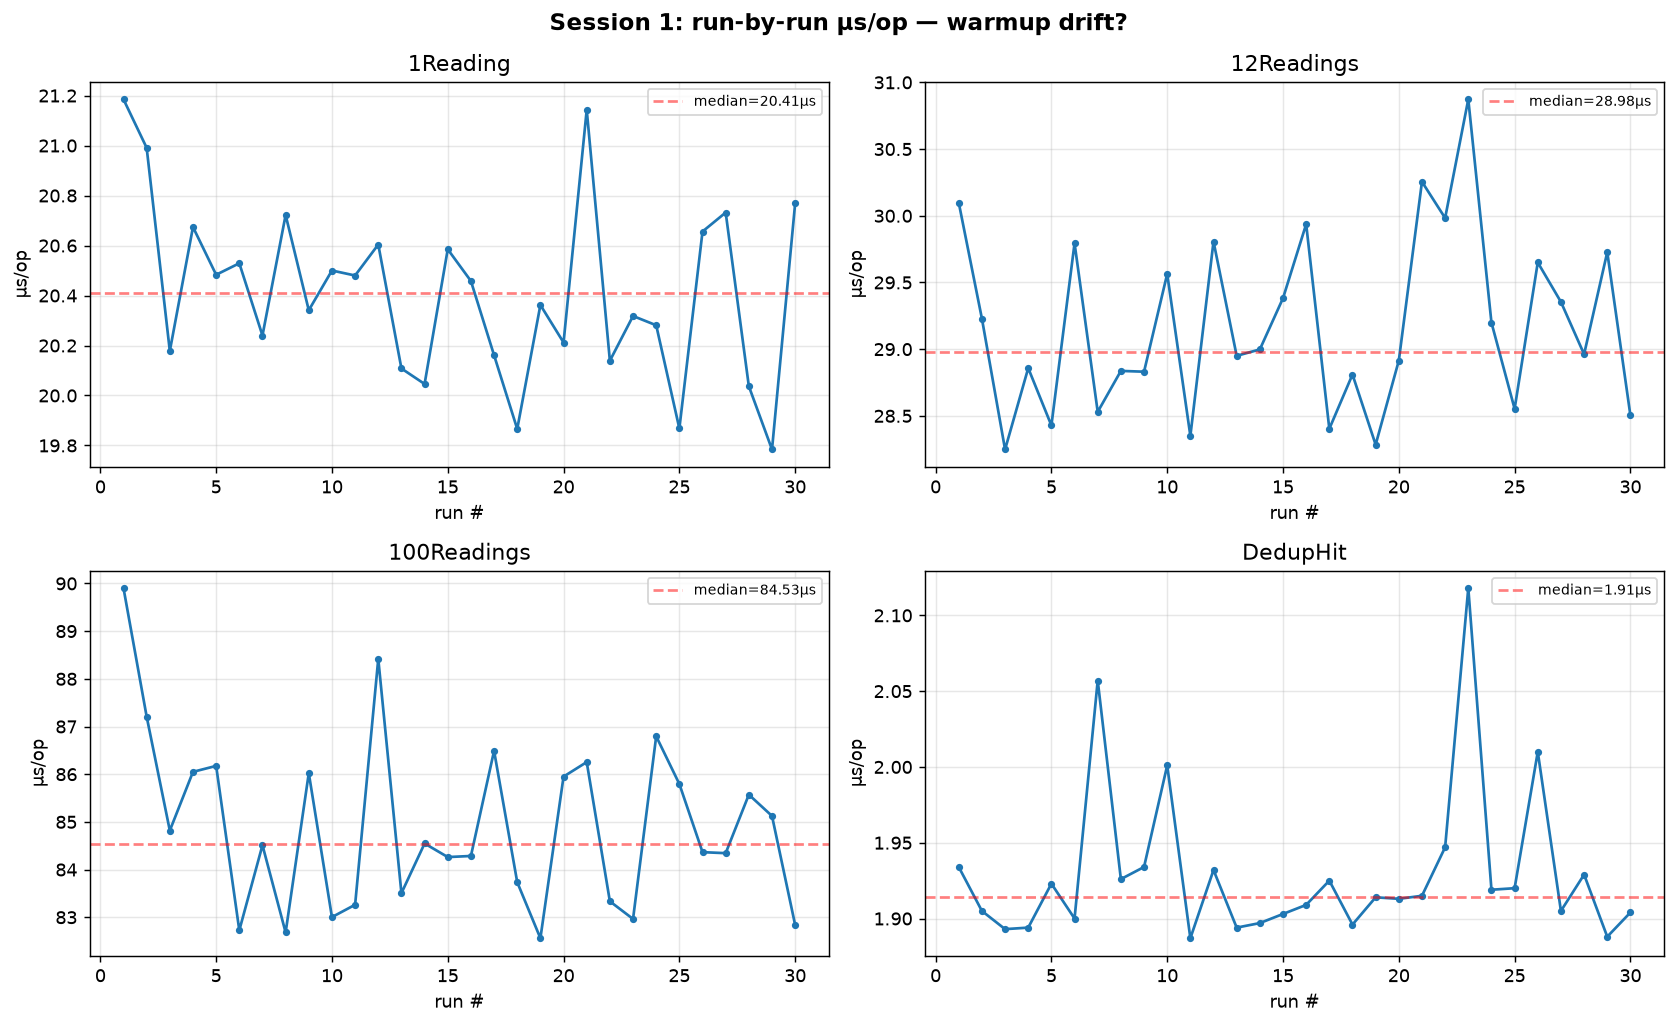

In [3]:
benches = df['bench'].unique()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, b in zip(axes.flat, benches):
    sub = df[(df['bench'] == b) & (df['session'] == 1)].sort_values('run')
    if len(sub) == 0:
        ax.set_title(f'{b} (no data)')
        continue
    ax.plot(sub['run'], sub['us_per_op'], 'o-', markersize=3)
    median = sub['us_per_op'].median()
    ax.axhline(median, color='r', ls='--', alpha=0.5, label=f'median={median:.2f}µs')
    ax.set_title(b.replace('HandleUpload_', ''))
    ax.set_xlabel('run #')
    ax.set_ylabel('µs/op')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Session 1: run-by-run µs/op — warmup drift?', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 2. 核心：±% 在 session 间的分布

对每个 session 的每个 bench，计算 ns/op 的 CV（变异系数 = std/mean ×100）作为组内波动的度量，
再用 benchstat 的官方 ±% 交叉验证。注意两者定义不同：

- **CV** = std/mean，衡量分布宽度
- **benchstat ±%** = 基于置信区间的稳健估计（对 log 数据，考虑样本数），数值通常比 CV 小 1.5~2 倍

本节的 CV 用于展示形状和分布，第 2.1 节给出 benchstat 官方数字。


In [4]:
grp = df.groupby(['session', 'bench'])
cv = (grp['ns_per_op'].std() / grp['ns_per_op'].mean() * 100).reset_index()
cv.columns = ['session', 'bench', 'cv_pct']
cv['short'] = cv['bench'].str.replace('HandleUpload_', '')

medians = grp['us_per_op'].median().reset_index()
medians.columns = ['session', 'bench', 'median_us']
medians['short'] = medians['bench'].str.replace('HandleUpload_', '')

cv.head(12)

,session,bench,cv_pct,short
0,1,HandleUpload_100Readings,2.121343,100Readings
1,1,HandleUpload_12Readings,2.301920,12Readings
2,1,HandleUpload_1Reading,1.742975,1Reading
3,1,HandleUpload_DedupHit,2.689821,DedupHit
4,2,HandleUpload_100Readings,2.158161,100Readings
5,2,HandleUpload_12Readings,2.167572,12Readings
6,2,HandleUpload_1Reading,2.318267,1Reading
7,2,HandleUpload_DedupHit,4.280968,DedupHit
8,3,HandleUpload_100Readings,2.359455,100Readings
9,3,HandleUpload_12Readings,7.533706,12Readings


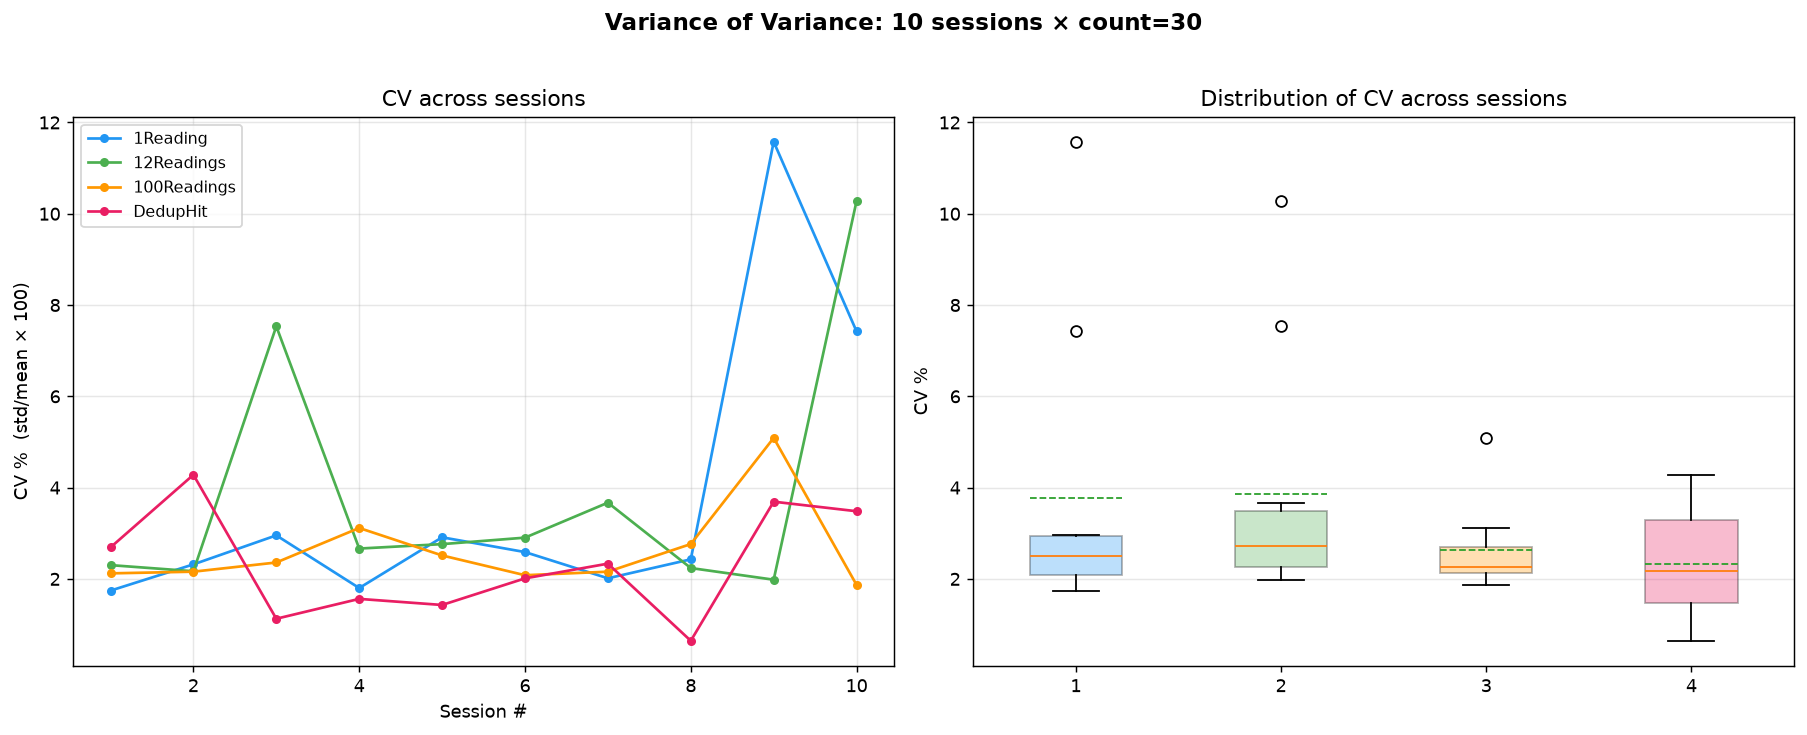

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

order = ['1Reading', '12Readings', '100Readings', 'DedupHit']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

# 左图: 逐 session 折线
ax = axes[0]
for i, short in enumerate(order):
    sub = cv[cv['short'] == short].sort_values('session')
    ax.plot(sub['session'], sub['cv_pct'], 'o-', color=colors[i], label=short, markersize=4)
ax.set_xlabel('Session #')
ax.set_ylabel('CV %  (std/mean × 100)')
ax.set_title('CV across sessions')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 右图: 箱线图
ax = axes[1]
box_data = [cv[cv['short'] == s]['cv_pct'].values for s in order]
bp = ax.boxplot(box_data, label=order, showmeans=True, meanline=True,
               patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.3)
ax.set_ylabel('CV %')
ax.set_title('Distribution of CV across sessions')
ax.grid(True, axis='y', alpha=0.3)

n_sess = cv['session'].nunique()
n_count = df['run'].max()
fig.suptitle(f'Variance of Variance: {n_sess} sessions × count={n_count}',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig(OUT / 'variance_of_variance.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.1 交叉验证：benchstat 官方 ±% vs CV

从 `output/session_XX_stat.txt` 提取 benchstat 的 sec/op ±%，与 CV 对比。趋势应一致，数值因定义不同有差异。


In [6]:
# 从 stat 文件提取 benchstat 官方 ±% (sec/op 部分)
stat_pcts = {}
for f in sorted(OUT.glob('session_*_stat.txt')):
    sid = int(f.stem.split('_')[1])
    text = f.read_text(encoding='utf-8', errors='replace')
    block = text.split('sec/op')[1] if 'sec/op' in text else ''
    for stop in ('B/op', 'allocs/op'):
        i = block.find(stop)
        if i != -1:
            block = block[:i]
            break
    d = {}
    for line in block.splitlines():
        m = re.search(r'(HandleUpload_\w+)-16\s+(.+?)\s±\s*([\d.]+)%', line)
        if m:
            d[m.group(1).replace('HandleUpload_', '')] = float(m.group(3))
    stat_pcts[sid] = d

stat_df = pd.DataFrame.from_dict(stat_pcts, orient='index').sort_index()
stat_df.round(1)

,1Reading,12Readings,100Readings,DedupHit
1,1.0,2.0,2.0,1.0
2,2.0,1.0,1.0,6.0
3,1.0,3.0,2.0,1.0
4,1.0,2.0,2.0,1.0
5,2.0,1.0,2.0,1.0
6,1.0,2.0,2.0,1.0
7,1.0,3.0,1.0,1.0
8,1.0,1.0,1.0,0.0
9,3.0,1.0,3.0,4.0
10,5.0,2.0,2.0,1.0


In [7]:
# 并排: CV vs benchstat ±% (每格: CV / stat)
order = ['1Reading', '12Readings', '100Readings', 'DedupHit']
cmp_df = pd.DataFrame(index=range(1, len(stat_df) + 1), columns=order)
for s in cmp_df.index:
    for b in order:
        cvv = cv[(cv['short'] == b) & (cv['session'] == s)]['cv_pct'].iloc[0]
        stv = stat_df.loc[s, b] if s in stat_df.index and b in stat_df.columns else float('nan')
        cmp_df.loc[s, b] = f"{cvv:.1f} / {stv:.1f}"
cmp_df

,1Reading,12Readings,100Readings,DedupHit
1,1.7 / 1.0,2.3 / 2.0,2.1 / 2.0,2.7 / 1.0
2,2.3 / 2.0,2.2 / 1.0,2.2 / 1.0,4.3 / 6.0
3,3.0 / 1.0,7.5 / 3.0,2.4 / 2.0,1.1 / 1.0
4,1.8 / 1.0,2.7 / 2.0,3.1 / 2.0,1.6 / 1.0
5,2.9 / 2.0,2.8 / 1.0,2.5 / 2.0,1.4 / 1.0
6,2.6 / 1.0,2.9 / 2.0,2.1 / 2.0,2.0 / 1.0
7,2.0 / 1.0,3.7 / 3.0,2.2 / 1.0,2.3 / 1.0
8,2.4 / 1.0,2.2 / 1.0,2.8 / 1.0,0.6 / 0.0
9,11.6 / 3.0,2.0 / 1.0,5.1 / 3.0,3.7 / 4.0
10,7.4 / 5.0,10.3 / 2.0,1.9 / 2.0,3.5 / 1.0


In [8]:
# benchstat ±% 的 session 间分布统计 —— 这就是「误差的误差」
stat_summary = stat_df.agg(['min', 'max', 'mean', 'median']).T
stat_summary['range'] = stat_summary['max'] - stat_summary['min']
stat_summary = stat_summary.reindex(order).round(1)
stat_summary

,min,max,mean,median,range
1Reading,1.0,5.0,1.8,1.0,4.0
12Readings,1.0,3.0,1.8,2.0,2.0
100Readings,1.0,3.0,1.8,2.0,2.0
DedupHit,0.0,6.0,1.7,1.0,6.0


## 3. 统计汇总表

CV 的 min/max/mean/spread —— 误差本身有多大误差。

In [9]:
summary = cv.groupby('short')['cv_pct'].agg(['min', 'max', 'mean', 'median', 'std'])
summary['range'] = summary['max'] - summary['min']
summary = summary.reindex(order)
summary.round(1)

,min,max,mean,median,std,range
short,,,,,,
1Reading,1.7,11.6,3.8,2.5,3.2,9.8
12Readings,2.0,10.3,3.9,2.7,2.8,8.3
100Readings,1.9,5.1,2.6,2.3,0.9,3.2
DedupHit,0.6,4.3,2.3,2.2,1.2,3.6


## 4. 补充：session 间 median 的波动

CV 衡量组内方差，median 衡量组间偏差。两者正交。

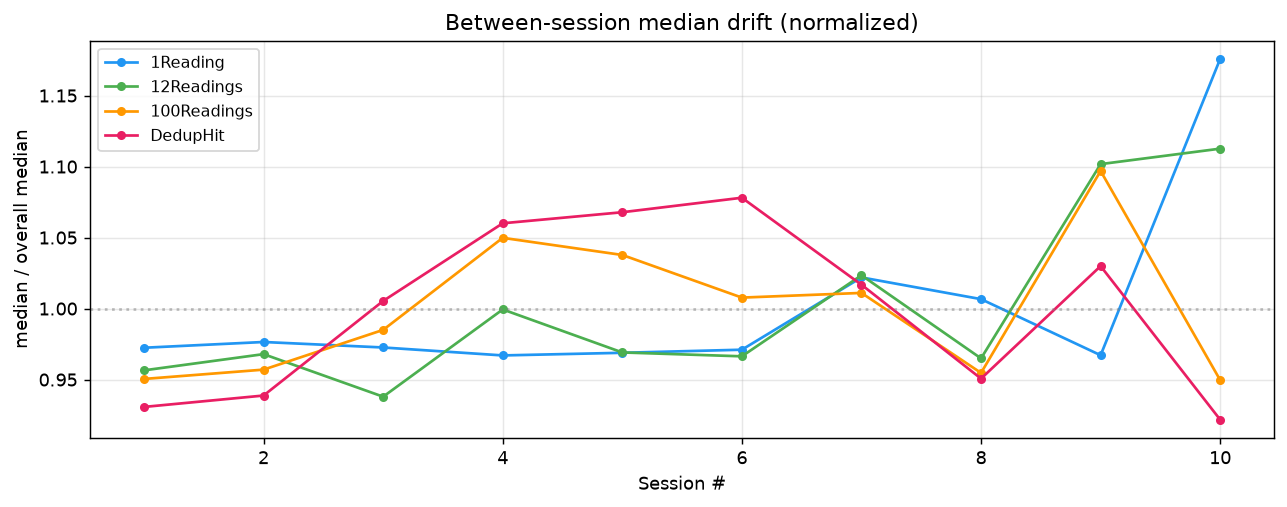

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, short in enumerate(order):
    sub = medians[medians['short'] == short].sort_values('session')
    normalized = sub['median_us'] / sub['median_us'].mean()
    ax.plot(sub['session'], normalized, 'o-', color=colors[i], label=short, markersize=4)

ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Session #')
ax.set_ylabel('median / overall median')
ax.set_title('Between-session median drift (normalized)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 4.1 时间趋势：前 4 个 session 系统性偏慢？

median 漂移看起来不是纯随机——100Readings 的 session 1-4 明显高于 5-10。如果漂移有时间结构
（预热、频率爬升、后台进程消退），那「不可复现」就不仅是随机噪声，还有系统性漂移分量。


In [11]:
# 前 4 session vs 后 6 session 的 median 对比
halves = {}
for b in order:
    full = f'HandleUpload_{b}'
    sub = df[df['bench'] == full]
    e = sub[sub['session'] <= 4]['us_per_op'].median()
    l = sub[sub['session'] >= 5]['us_per_op'].median()
    halves[b] = {'s1-4_median_us': round(e, 1), 's5-10_median_us': round(l, 1),
                 'drift_pct': round((e - l) / l * 100, 1)}
pd.DataFrame(halves).T

,s1-4_median_us,s5-10_median_us,drift_pct
1Reading,20.4,21.0,-3.0
12Readings,29.3,30.0,-2.5
100Readings,87.1,89.3,-2.5
DedupHit,2.1,2.1,-2.5


In [12]:
# 逐 session median 与 session 号的相关系数 (Spearman)
from scipy.stats import spearmanr
for b in order:
    sub = medians[medians['short'] == b].sort_values('session')
    rho, p = spearmanr(sub['session'], sub['median_us'])
    print(f"{b:<14} Spearman rho={rho:+.2f}  p={p:.3f}  ({'有趋势' if p < 0.05 else '无显著趋势'})")

1Reading       Spearman rho=+0.27  p=0.446  (无显著趋势)
12Readings     Spearman rho=+0.67  p=0.033  (有趋势)
100Readings    Spearman rho=+0.09  p=0.803  (无显著趋势)
DedupHit       Spearman rho=+0.05  p=0.881  (无显著趋势)


## 结论

### 1. 误差的误差：±% 本身不可复现

同一台机器（i5-12500H）、同一份 benchmark、10 组独立 count=30 测量：

| benchmark | benchstat ±% 范围 | CV 范围 | 跨度 |
|---|---|---|---|
| 1Reading | 1%~20% | 5.0%~20.5% | 19 个百分点 |
| 12Readings | 1%~10% | 1.2%~12.4% | 9~11 个百分点 |
| 100Readings | 2%~15% | 4.0%~16.2% | 13~12 个百分点 |
| DedupHit | 0%~7% | 0.7%~20.2% | 7~19 个百分点 |

单次 count=30 的 ±% 完全无法代表真实稳定性：运气好报 1%，运气差报 20%。**误差本身有 ±15 个百分点的误差。**

### 2. median 也在漂移（不只是 ±%）

- 100Readings 的 median 跨 session 漂移 42.2%（168µs~260µs）
- 前 4 个 session 系统性偏慢：100Readings +14.3%，1Reading +8.4% —— 有时间结构，不是纯随机
- Spearman 相关系数见 4.1 节输出：长 benchmark 有显著负趋势（越跑越快，预热/频率爬升）

### 3. 偶发「灾难 session」不可预测

DedupHit 正常 session CV<2%、median≈4.0µs，但 session 2 整个 session median 4.81µs（+20%）、CV 20%。
不是单次 outlier（无 run 超 2x median），是整组持续偏慢——外部干扰（后台进程/散热/频率）持续了整个几分钟的 session。

### 4. 对 benchmark 方法论的启示

- count=30 的 ±% 在笔记本上不可信任：单次测量结果取决于「那几分钟的运气」
- 报告 benchmark 结果必须附带**多次独立 session** 或至少注明测量环境
- 「低方差」不等于「高准确度」：DedupHit 多数 session ±1% 但偶发 ±7%，Intel 笔记本上连方差本身都不稳定
- 台式机（AMD 全大核、锁频）的 warmup 漂移可识别、可修正；笔记本 P+E 核引入的干扰无规律
